In [20]:
import sys
import os
import math
import glob
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
sys.path.append('..')

# Project modules
from src.utility.config import (
    DEVICE, 
    CSV_DIR,
    BASELINE_MODEL_PATH, 
    QUANTIZED_MODELS, 
    EXPERIMENT_CONFIGS,
    DATASET_NAME
)
from src.utility.quantizer import Quantization
from src.utility.utils import get_data_loaders, get_model_size, activate_quantization_flags
from src.model import CNN
from src.layers import QuantizedLayerMixin
from src.evaluation.evaluate import evaluate
sns.set_theme(style="whitegrid")

In [21]:
def load_quantized_model_correctly(model, path, device):
    """
    Lädt ein quantisiertes Modell und repariert die Datentypen, 
    die load_state_dict() versehentlich zu Float konvertiert hat.
    """
    # 1. State Dict laden (PyTorch konvertiert hier INT8 -> Float32!)
    state_dict = torch.load(path, map_location=device)
    model.load_state_dict(state_dict)
    
    print(f"Repariere Quantisierungs-Zustand für: {path}")
    
    for name, module in model.named_modules():
        if isinstance(module, QuantizedLayerMixin):
            # A) Metadaten wiederherstellen (falls nötig)
            # Wir versuchen, anhand des Namens oder Config zu raten, 
            # aber oft reicht es, den Buffer 'weight_scale' zu prüfen.
            
            # B) Flags setzen
            module.quant_mode = True
            if module.act_scale.item() != 1.0:
                module.activation_calibrated = True
            
            # C) CRITICAL FIX: Datentyp reparieren
            # Wenn das Gewicht Float ist, aber wir im Quant-Mode sind, 
            # müssen wir prüfen, ob es eigentlich Int sein sollte.
            
            # Wir entscheiden basierend auf der Methode (die wir setzen müssen)
            # Da Python-Variablen weg sind, müssen wir sie übergeben oder raten.
            # Hier: Wir schauen einfach, was "logischer" ist oder übergeben es.
            
            # Da wir die Methode im Loop schwer raten können, 
            # machen wir es robust: Wir schauen, ob die Werte "ganzzahlig" aussehen 
            # oder wir nutzen den Config-Namen von außen.
            pass 

    return model

In [22]:
def setup_quantized_layer(module, method, bits):
    """Hilfsfunktion, um einen Layer korrekt zu konfigurieren"""
    module.quant_method = method
    module.num_bits = bits
    module.quant_mode = True
    
    if module.act_scale.item() != 1.0:
        module.activation_calibrated = True
        
    # DER FIX: Gewicht wieder zu Int casten
    if method == 'affine':
        target_dtype = torch.uint8
    else: # symmetric / power2
        target_dtype = torch.int8
        
    # Nur casten, wenn es noch Float ist (durch load_state_dict)
    if module.weight.dtype == torch.float32:
        # Wir casten die Float-Werte (z.B. 100.0) zurück zu Int (100)
        # .data ist wichtig, um Autograd nicht zu verwirren
        module.weight = nn.Parameter(module.weight.data.to(target_dtype), requires_grad=False)
        # print(f"  -> Fixed dtype to {target_dtype}")

In [23]:
# 1. Load Data
print("Lade Daten...")
train_loader, test_loader, num_classes = get_data_loaders()

# ---------------------------------------------------------
# A) BASELINE MODELL LADEN
# ---------------------------------------------------------
baseline_model = CNN(num_classes=num_classes).to(DEVICE)

# Liste möglicher Dateinamen (Config-Name vs. Alter Name)
possible_paths = [
    BASELINE_MODEL_PATH,                                 
    os.path.join(os.path.dirname(BASELINE_MODEL_PATH), "baseline_float32.pt")
]

found_baseline = False
for path in possible_paths:
    if os.path.exists(path):
        baseline_model.load_state_dict(torch.load(path, map_location=DEVICE))
        baseline_model.convert_to_baseline() 
        baseline_model.eval()
        print(f"✅ Baseline geladen: {path}")
        found_baseline = True
        break

if not found_baseline:
    print(f"❌ FEHLER: Kein Baseline-Modell gefunden. Gesucht in: {possible_paths}")

# ---------------------------------------------------------
# B) QUANTISIERTES MODELL LADEN
# ---------------------------------------------------------
config_name = "Sym_INT8" 
quant_path = os.path.join(QUANTIZED_MODELS, f"model_{config_name}.pt")

quantized_model = CNN(num_classes=num_classes).to(DEVICE)

if os.path.exists(quant_path):
    # 1. Laden (Gewichte werden fälschlicherweise Float)
    quantized_model.load_state_dict(torch.load(quant_path, map_location=DEVICE))

    # 2. Infos ableiten
    method = 'symmetric' if 'Sym' in config_name else 'affine'
    if 'Po2' in config_name: method = 'power2'
    bits = 4 if 'INT4' in config_name else 8
    
    print(f"🔧 Repariere Modell (Method={method}, Bits={bits})...")
    
    # 3. Layer reparieren
    for name, module in quantized_model.named_modules():
        if hasattr(module, "quant_mode"):
            setup_quantized_layer(module, method, bits)
            
    quantized_model.eval()
    print(f"✅ Quantized Model bereit: {quant_path}")
    
    # Jetzt sollte die Accuracy stimmen!
    # assess_classification_performance(...)

else:
    print(f"❌ Modell nicht gefunden: {quant_path}")

Lade Daten...
✅ Baseline geladen: c:\Users\Dominic\Documents\ResearchProject\results\models\baseline_float32.pt
🔧 Repariere Modell (Method=symmetric, Bits=8)...
✅ Quantized Model bereit: c:\Users\Dominic\Documents\ResearchProject\results\quantized_models\model_Sym_INT8.pt


In [24]:
def visualize_comparison(model_f, model_q, test_loader, num_images=50):
    
    data_list, target_list = [], []
    for d, t in test_loader:
        data_list.append(d)
        target_list.append(t)
        if len(torch.cat(data_list)) >= num_images:
            break
            
    
    data = torch.cat(data_list)[:num_images].to(DEVICE)
    target = torch.cat(target_list)[:num_images].to(DEVICE)

    
    with torch.no_grad():
        out_f = model_f(data)
        out_q = model_q(data)
    pred_f = out_f.argmax(dim=1)
    pred_q = out_q.argmax(dim=1)

    
    cols = 8 
    rows = math.ceil(num_images / cols)
    
    fig, axes = plt.subplots(rows, cols, figsize=(20, 3.5 * rows))
    axes_flat = axes.flatten() 

    if hasattr(test_loader.dataset, 'classes'):
        class_names = test_loader.dataset.classes
    elif hasattr(test_loader.dataset, 'dataset') and hasattr(test_loader.dataset.dataset, 'classes'):
        class_names = test_loader.dataset.dataset.classes
    else:
        # Fallback falls keine Klassen namen da sind
        class_names = [str(i) for i in range(1000)]

    print(f"Zeige {num_images} Bilder. Legende: Grün=Korrekt, Rot=Falsch, Orange=Quantisierung weicht ab")

    for i in range(num_images):
        ax = axes_flat[i]
       
        img = data[i].cpu().permute(1, 2, 0).numpy()
        img = img * 0.5 + 0.5 
        img = np.clip(img, 0, 1) 

        ax.imshow(img)
        
        p_q_idx = pred_q[i].item()
        p_f_idx = pred_f[i].item()
        real_idx = target[i].item()
        
        name_q = class_names[p_q_idx]
        name_real = class_names[real_idx]

        is_correct = (p_q_idx == real_idx)
        has_changed = (p_q_idx != p_f_idx) 

        if has_changed:
            color = 'orange'
            
            title_text = f"Q: {name_q}\n(F: {class_names[p_f_idx]})"
        else:
            color = 'green' if is_correct else 'red'
            title_text = f"Pred: {name_q}\nReal: {name_real}"

        ax.set_title(title_text, color=color, fontsize=10, fontweight='bold')
        ax.axis('off')
        
    for j in range(num_images, len(axes_flat)):
        axes_flat[j].axis('off')

    plt.tight_layout()
    plt.show()

In [25]:
def assess_classification_performance(model, data_loader, device, model_name="Model"):
   
    model.eval() 
    
    all_targets = []
    all_predictions = []
    
    print(f"--- Starte Assessment für: {model_name} ---")
    
    with torch.no_grad():
        for inputs, targets in data_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            outputs = model(inputs)
            
            _, predicted = torch.max(outputs, 1)
            
            all_predictions.extend(predicted.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())

    acc = accuracy_score(all_targets, all_predictions)
    
    error_rate = 1.0 - acc
    
    print(f"Accuracy:   {acc:.4f} ({acc*100:.2f}%)")
    print(f"Error Rate: {error_rate:.4f} ({error_rate*100:.2f}%)")
    
    print("\n>>> Detailed Classification Report (Precision, Recall, F-Measure):")
    print(classification_report(all_targets, all_predictions, digits=4, zero_division=0))    
    TOP_N = 15 
    
    from collections import Counter
    class_counts = Counter(all_targets)
    
    top_classes = [cls for cls, count in class_counts.most_common(TOP_N)]
    
    mask = [t in top_classes and p in top_classes for t, p in zip(all_targets, all_predictions)]
    
    subset_targets = [t for t, m in zip(all_targets, mask) if m]
    subset_preds = [p for p, m in zip(all_predictions, mask) if m]
    
    if len(subset_targets) > 0:
        cm = confusion_matrix(subset_targets, subset_preds, labels=top_classes)

        plt.figure(figsize=(10, 8))
        try:
            import seaborn as sns
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                        xticklabels=top_classes, yticklabels=top_classes)
        except ImportError:
            disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=top_classes)
            disp.plot(cmap='Blues', values_format='d', ax=plt.gca())

        plt.title(f"Confusion Matrix (Top {TOP_N} Frequent Classes) - {model_name}")
        plt.xlabel('Predicted Class')
        plt.ylabel('True Class')
        plt.show()
    else:
        print("Zu wenige Datenpunkte für das Subset-Plotting.")

    return acc

In [26]:
def get_predictions(model, loader):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            
    return np.array(all_labels), np.array(all_preds)

# Predictions holen
print("Generiere Vorhersagen für Baseline...")
y_true, y_pred_base = get_predictions(baseline_model, test_loader)

print("Generiere Vorhersagen für Quantized...")
_, y_pred_quant = get_predictions(quantized_model, test_loader)

Generiere Vorhersagen für Baseline...
Generiere Vorhersagen für Quantized...


In [27]:
def plot_layer_weight_ranges(model):
    layer_names = []
    weight_data = []
    
    for name, module in model.named_modules():
        # Wir schauen uns Conv2d und Linear Layer an
        if isinstance(module, (torch.nn.Conv2d, torch.nn.Linear)):
            # Gewichte holen und flach machen
            w = module.weight.detach().cpu().numpy().flatten()
            
            layer_names.append(name)
            weight_data.append(w)
            
    # Plot
    plt.figure(figsize=(14, 6))
    plt.boxplot(weight_data, tick_labels=layer_names, showfliers=False) # showfliers=False blendet extreme Outlier aus für bessere Lesbarkeit
    
    plt.title("Gewichts-Verteilung pro Layer (Range)")
    plt.ylabel("Gewichtswert")
    plt.xticks(rotation=45)
    plt.grid(True, axis='y', alpha=0.5)
    
    # Rote Linie bei 0
    plt.axhline(0, color='red', linestyle='--', linewidth=0.8)
    
    plt.tight_layout()
    plt.show()

In [ ]:
def compare_weights_float_vs_quantized(float_model, quant_model, layer_name, title_suffix=""):
    
    # 1. Module finden
    float_modules = dict(float_model.named_modules())
    quant_modules = dict(quant_model.named_modules())
    
    if layer_name not in float_modules or layer_name not in quant_modules:
        print(f"❌ Layer {layer_name} nicht gefunden.")
        return

    float_module = float_modules[layer_name]
    quant_module = quant_modules[layer_name]

    # 2. Daten extrahieren
    # A) Original Float
    w_original = float_module.weight.detach().cpu().flatten().numpy()
    
    # B) Quantized Int (Das sind jetzt echte Integers, z.B. -128 bis 127)
    w_quant_int = quant_module.weight.detach().cpu().flatten().float() # Cast zu float nur fürs Plotten/Rechnen
    
    # C) Optional: Dequantized (um den Informationsverlust direkt vergleichbar zu machen)
    # Formel: (q - ZP) * Scale
    scale = quant_module.weight_scale.item()
    zp = quant_module.weight_zero_point.item()
    w_dequant = (w_quant_int - zp) * scale
    w_dequant = w_dequant.numpy()

    # 3. Plotten
    plt.figure(figsize=(15, 5))

    # Plot 1: Original Float
    plt.subplot(1, 3, 1)
    sns.histplot(w_original, bins=50, kde=True, color='blue')
    plt.title(f"{layer_name} - Original Float32\n(Range: {w_original.min():.2f} to {w_original.max():.2f})")
    plt.xlabel("Weight Value (Float)")

    # Plot 2: Echte Integers (Was im Speicher liegt)
    plt.subplot(1, 3, 2)
    # Wir nehmen w_quant_int (die rohen Zahlen)
    sns.histplot(w_quant_int.numpy(), bins=50, kde=False, color='green')
    plt.title(f"{layer_name} - {title_suffix} (Storage)\n(Int Values: {int(w_quant_int.min())} to {int(w_quant_int.max())})")
    plt.xlabel("Discrete Integer Value")

    # Plot 3: De-Quantized (Der "Treppchen-Effekt")
    # Zeigt, wie das Modell die Welt jetzt "sieht"
    plt.subplot(1, 3, 3)
    sns.histplot(w_dequant, bins=50, kde=True, color='red')
    plt.title(f"{layer_name} - Dequantized View\n(Approximation)")
    plt.xlabel("Weight Value (Reconstructed)")

    plt.tight_layout()
    plt.show()

--- Vergleiche Accuracy pro Klasse ---


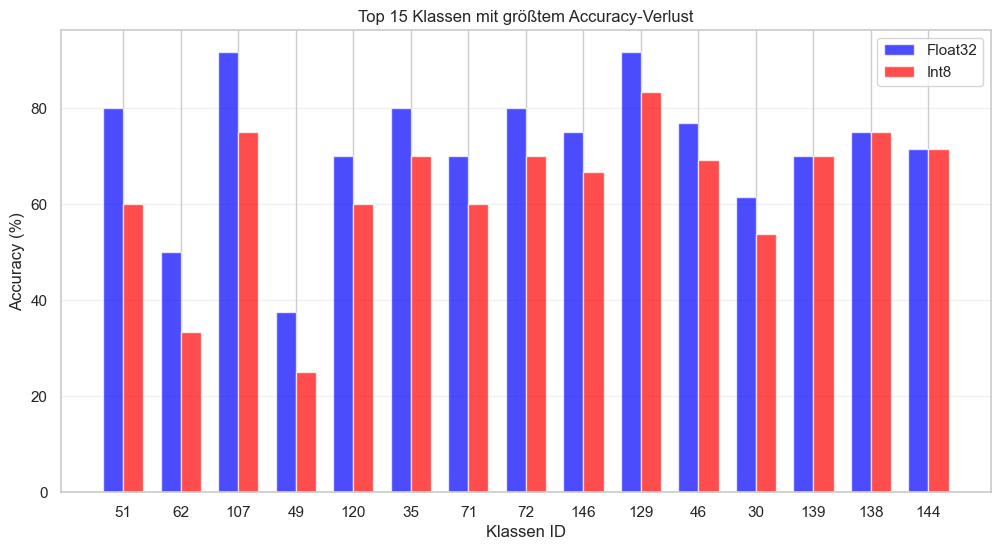

In [29]:
def plot_per_class_accuracy_comparison(model_float, model_quant, loader, class_names=None):
    model_float.eval()
    model_quant.eval()
    
    correct_float = {}
    correct_quant = {}
    total_count = {}
    
    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(DEVICE), target.to(DEVICE)
            
            # Float Preds
            out_f = model_float(data)
            pred_f = out_f.argmax(dim=1)
            
            # Quant Preds
            out_q = model_quant(data)
            pred_q = out_q.argmax(dim=1)
            
            for i in range(len(target)):
                label = target[i].item()
                total_count[label] = total_count.get(label, 0) + 1
                
                if pred_f[i] == label:
                    correct_float[label] = correct_float.get(label, 0) + 1
                
                if pred_q[i] == label:
                    correct_quant[label] = correct_quant.get(label, 0) + 1

    classes = sorted(total_count.keys())
    acc_f = [correct_float.get(c, 0) / total_count[c] * 100 for c in classes]
    acc_q = [correct_quant.get(c, 0) / total_count[c] * 100 for c in classes]
    

    diffs = [f - q for f, q in zip(acc_f, acc_q)]
    
    sorted_indices = np.argsort(diffs)[::-1][:15] # Top 15 Drops
    
    top_classes = [str(c) for c in np.array(classes)[sorted_indices]]
    top_acc_f = np.array(acc_f)[sorted_indices]
    top_acc_q = np.array(acc_q)[sorted_indices]
    
    x = np.arange(len(top_classes))
    width = 0.35
    
    plt.figure(figsize=(12, 6))
    plt.bar(x - width/2, top_acc_f, width, label='Float32', color='blue', alpha=0.7)
    plt.bar(x + width/2, top_acc_q, width, label='Int8', color='red', alpha=0.7)
    
    plt.xlabel('Klassen ID')
    plt.ylabel('Accuracy (%)')
    plt.title('Top 15 Klassen mit größtem Accuracy-Verlust')
    plt.xticks(x, top_classes)
    plt.legend()
    plt.grid(True, axis='y', alpha=0.3)
    plt.show()

print("--- Vergleiche Accuracy pro Klasse ---")
plot_per_class_accuracy_comparison(baseline_model, quantized_model, test_loader)

Lade Ergebnisse aus: c:\Users\Dominic\Documents\ResearchProject\results\csv\quantization_results_POKEMON.csv


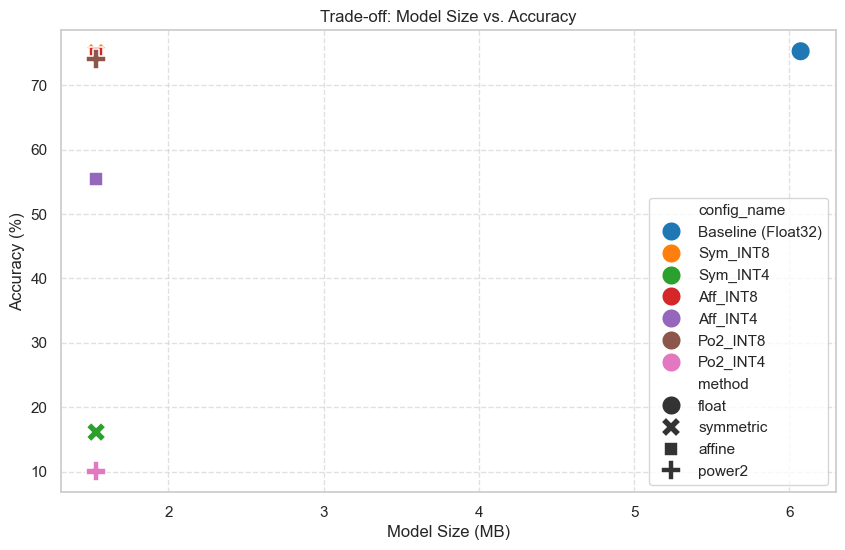

,config_name,accuracy,model_size_mb,inference_time,drop_percentage
0,Baseline (Float32),75.293255,6.072220,4.409352,0.000000
1,Sym_INT8,75.073314,1.533902,7.233610,0.219941
2,Sym_INT4,16.129032,1.533902,6.984407,59.164223
3,Aff_INT8,74.926686,1.533902,7.190184,0.366569
4,Aff_INT4,55.498534,1.533902,7.229777,19.794721
5,Po2_INT8,74.120235,1.533902,7.318318,1.173021
6,Po2_INT4,10.043988,1.533902,7.224945,65.249267


In [30]:
csv_files = glob.glob(os.path.join(CSV_DIR, "quantization_results_*.csv"))
if csv_files:
    latest_csv = max(csv_files, key=os.path.getctime)
    print(f"Lade Ergebnisse aus: {latest_csv}")
    df_results = pd.read_csv(latest_csv)
    
    plt.figure(figsize=(10, 6))
    
    sns.scatterplot(
        data=df_results, 
        x='model_size_mb', 
        y='accuracy', 
        hue='config_name', 
        style='method', 
        s=200, # Basisgröße
        palette='tab10'
    )

    plt.title("Trade-off: Model Size vs. Accuracy")
    plt.xlabel("Model Size (MB)")
    plt.ylabel("Accuracy (%)")
    plt.grid(True, linestyle='--', alpha=0.6)
    
    plt.show()
    
    display(df_results[['config_name', 'accuracy', 'model_size_mb', 'inference_time', 'drop_percentage']])

else:
    print("Keine Ergebnis-CSV gefunden. Hast du main_experiment.py schon komplett laufen lassen?")

Lade Sensitivitäts-Daten: c:\Users\Dominic\Documents\ResearchProject\results\csv\sensitivity_analysis.csv


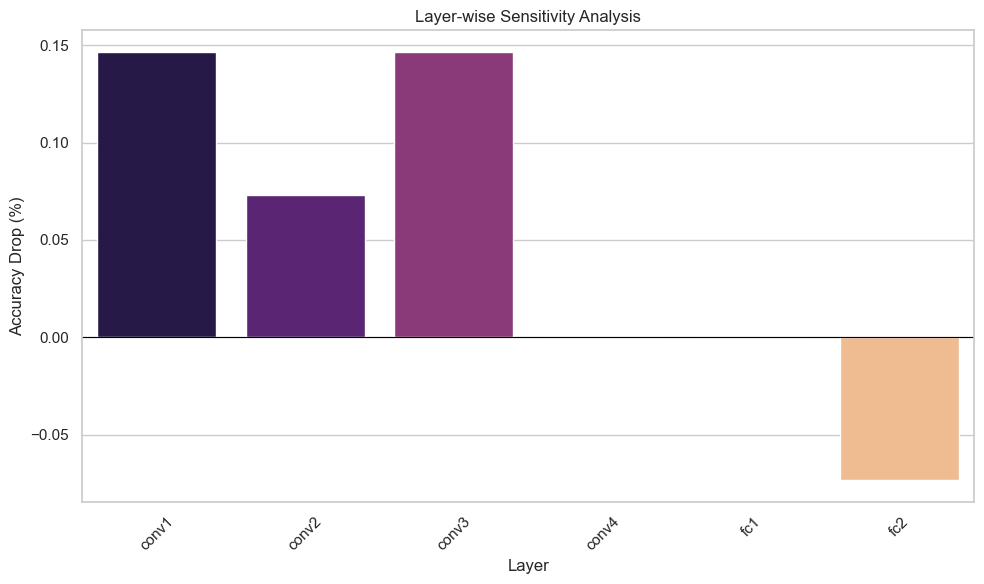

,layer_name,accuracy,drop
0,conv1,75.146628,0.146628
2,conv3,75.146628,0.146628
1,conv2,75.219941,0.073314
3,conv4,75.293255,0.000000
4,fc1,75.293255,0.000000
5,fc2,75.366569,-0.073314


In [31]:
csv_files = glob.glob(os.path.join(CSV_DIR, "sensitivity_*.csv"))

if csv_files:
    # Neueste Datei nehmen
    latest_csv = max(csv_files, key=os.path.getctime)
    print(f"Lade Sensitivitäts-Daten: {latest_csv}")
    
    df_sens = pd.read_csv(latest_csv)
    
    # Plotting
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_sens, x='layer_name', y='drop', hue='layer_name', legend=False, palette='magma')
    
    plt.title("Layer-wise Sensitivity Analysis")
    plt.ylabel("Accuracy Drop (%)")
    plt.xlabel("Layer")
    plt.xticks(rotation=45)
    plt.axhline(0, color='black', linewidth=0.8)
    plt.tight_layout()
    plt.show()
    
    # Tabelle anzeigen
    display(df_sens.sort_values(by='drop', ascending=False))
else:
    print("Keine Sensitivitäts-CSV gefunden. Bitte erst main_experiment.py ausführen.")

--- Analyse der Gewichtsverteilung (Float Model) ---


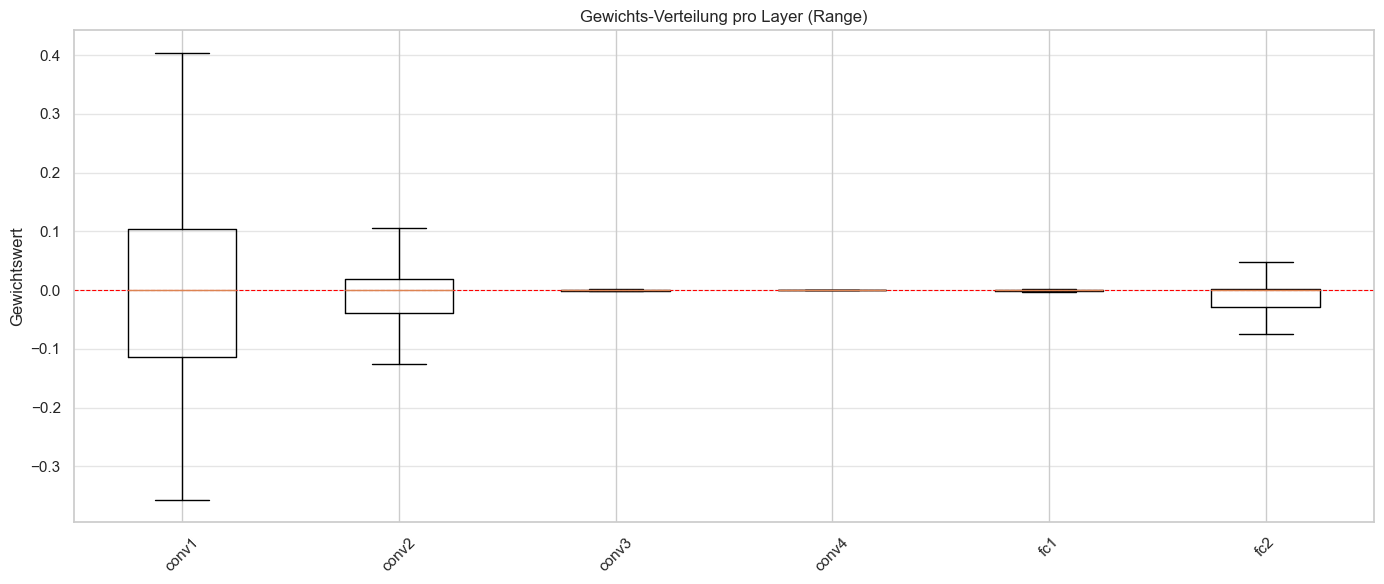

In [32]:
print("--- Analyse der Gewichtsverteilung (Float Model) ---")
# Am besten am Baseline-Modell ausführen, um die "echten" Ranges zu sehen
plot_layer_weight_ranges(baseline_model)

--- Visualisierung für Sym_INT8 ---


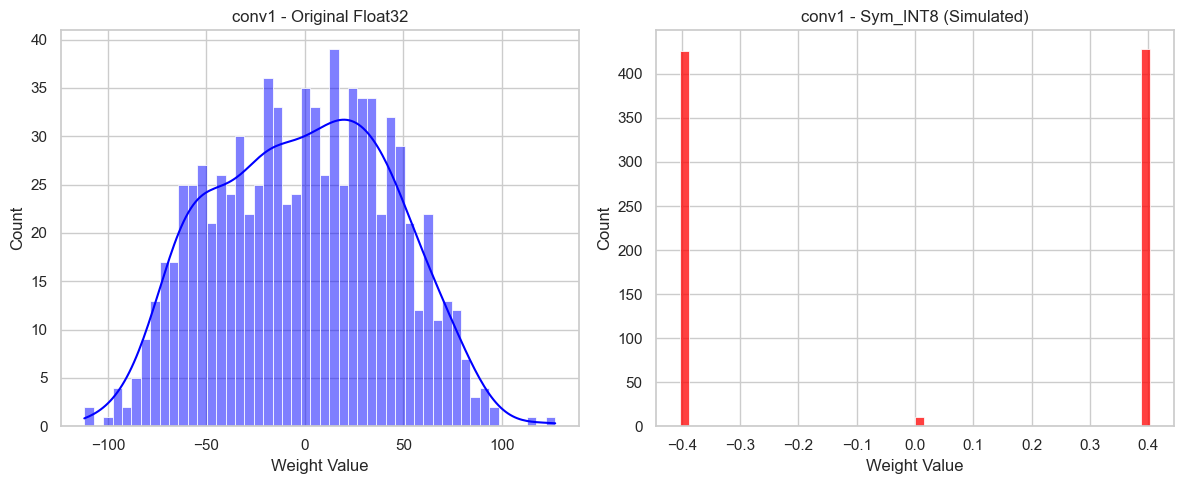

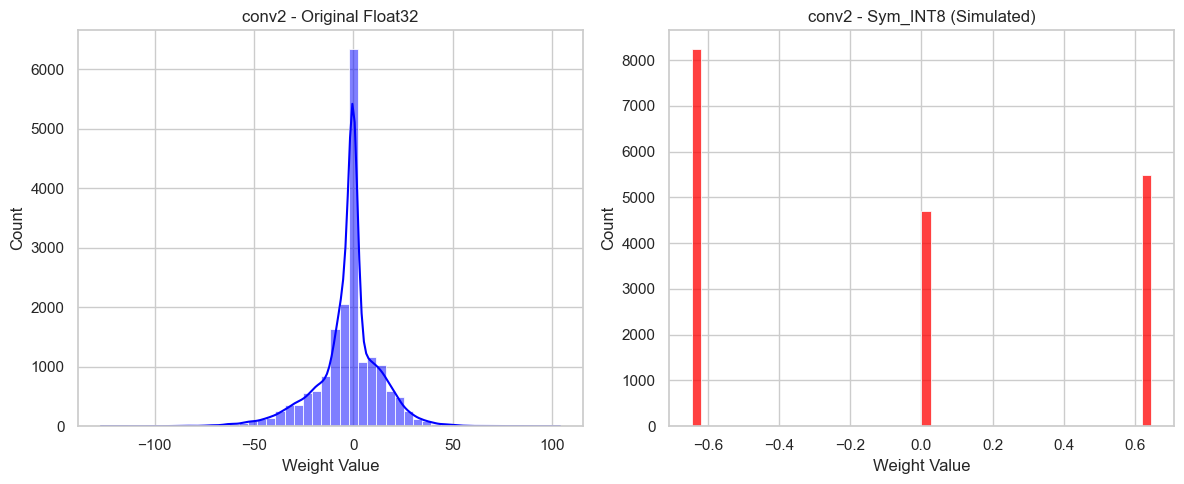

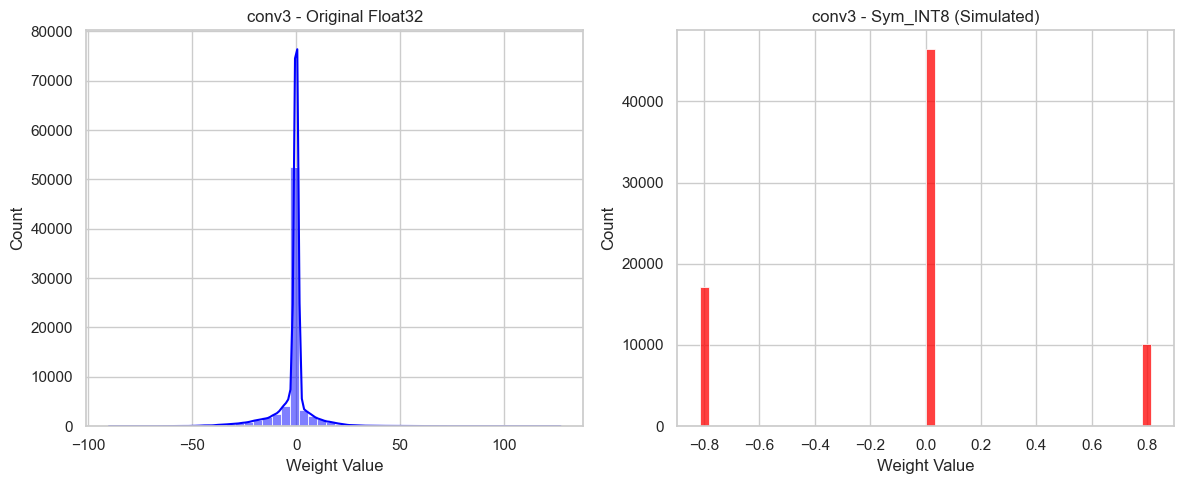

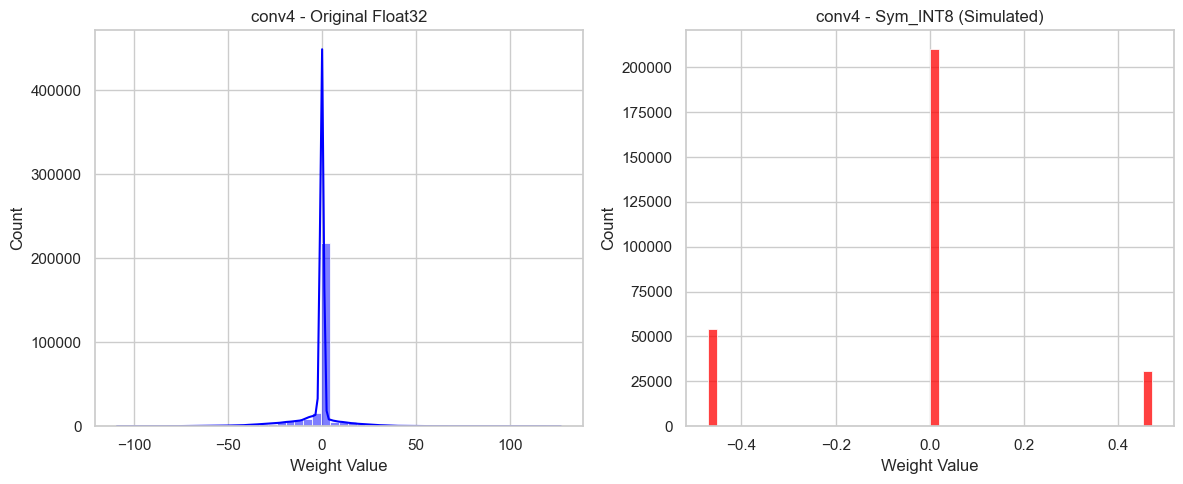

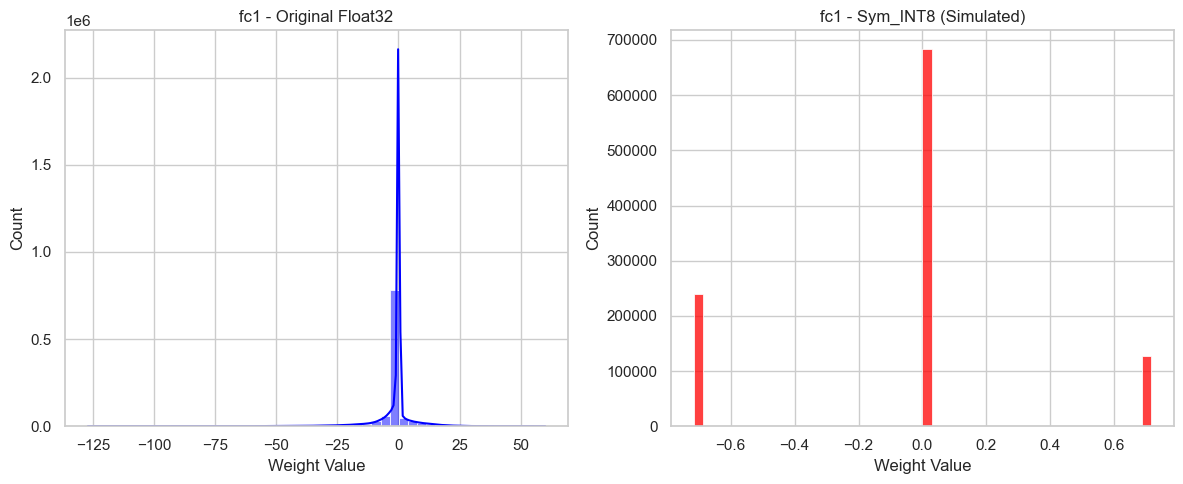

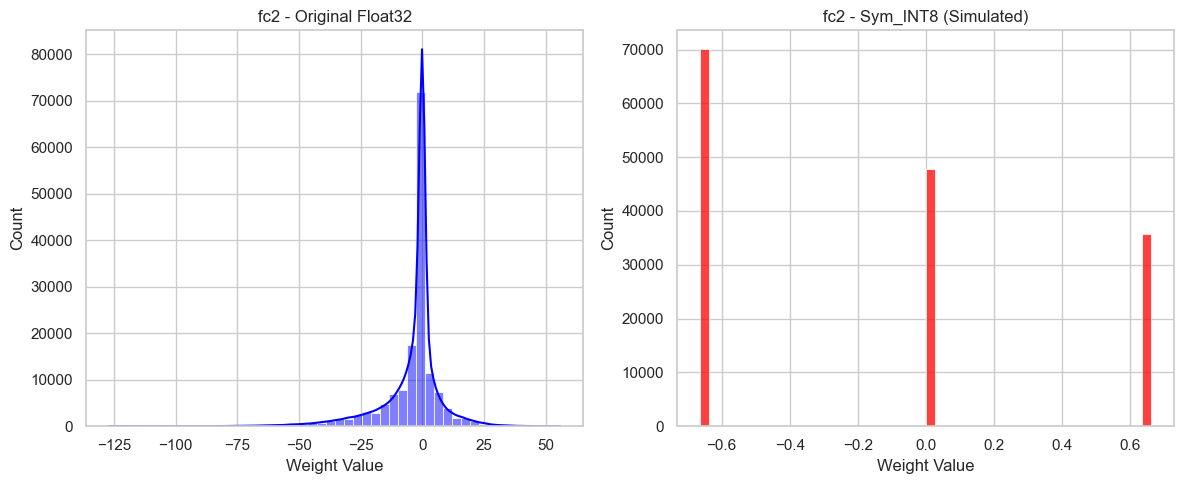

In [37]:
print(f"--- Visualisierung für {config_name} ---")
plot_weight_distribution(quantized_model, "conv1", title_suffix=config_name)
plot_weight_distribution(quantized_model, "conv2", title_suffix=config_name)
plot_weight_distribution(quantized_model, "conv3", title_suffix=config_name)
plot_weight_distribution(quantized_model, "conv4", title_suffix=config_name)

plot_weight_distribution(quantized_model, "fc1", title_suffix=config_name)
plot_weight_distribution(quantized_model, "fc2", title_suffix=config_name)

--- Starte Assessment für: Baseline (Float32) ---
Accuracy:   0.7529 (75.29%)
Error Rate: 0.2471 (24.71%)

>>> Detailed Classification Report (Precision, Recall, F-Measure):
              precision    recall  f1-score   support

           0     0.7778    0.7778    0.7778         9
           1     0.7000    0.7000    0.7000        10
           2     0.4545    1.0000    0.6250         5
           3     1.0000    0.1111    0.2000         9
           4     0.6250    1.0000    0.7692         5
           5     0.9000    0.7500    0.8182        12
           6     0.5833    1.0000    0.7368         7
           7     0.7778    1.0000    0.8750         7
           8     1.0000    0.8000    0.8889        10
           9     0.3750    1.0000    0.5455         3
          10     1.0000    1.0000    1.0000         6
          11     0.8000    1.0000    0.8889         4
          12     0.0000    0.0000    0.0000         1
          13     0.9000    0.7500    0.8182        12
          14   

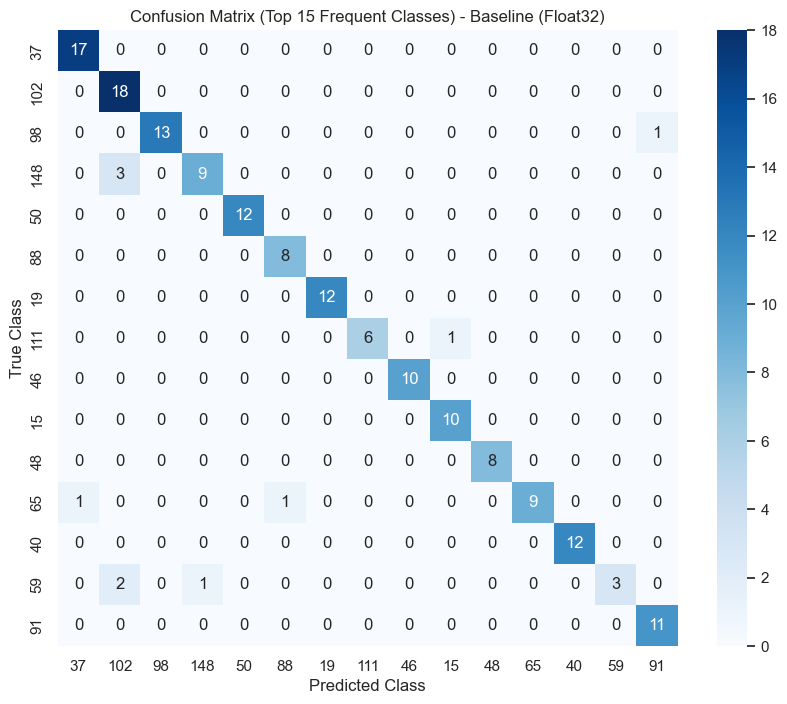

--- Starte Assessment für: Quantized (Sym_INT8) ---
Accuracy:   0.7507 (75.07%)
Error Rate: 0.2493 (24.93%)

>>> Detailed Classification Report (Precision, Recall, F-Measure):
              precision    recall  f1-score   support

           0     0.8750    0.7778    0.8235         9
           1     0.6364    0.7000    0.6667        10
           2     0.4545    1.0000    0.6250         5
           3     1.0000    0.1111    0.2000         9
           4     0.6250    1.0000    0.7692         5
           5     0.9000    0.7500    0.8182        12
           6     0.5000    1.0000    0.6667         7
           7     0.7778    1.0000    0.8750         7
           8     1.0000    0.8000    0.8889        10
           9     0.4286    1.0000    0.6000         3
          10     1.0000    1.0000    1.0000         6
          11     1.0000    1.0000    1.0000         4
          12     0.0000    0.0000    0.0000         1
          13     0.9000    0.7500    0.8182        12
          14 

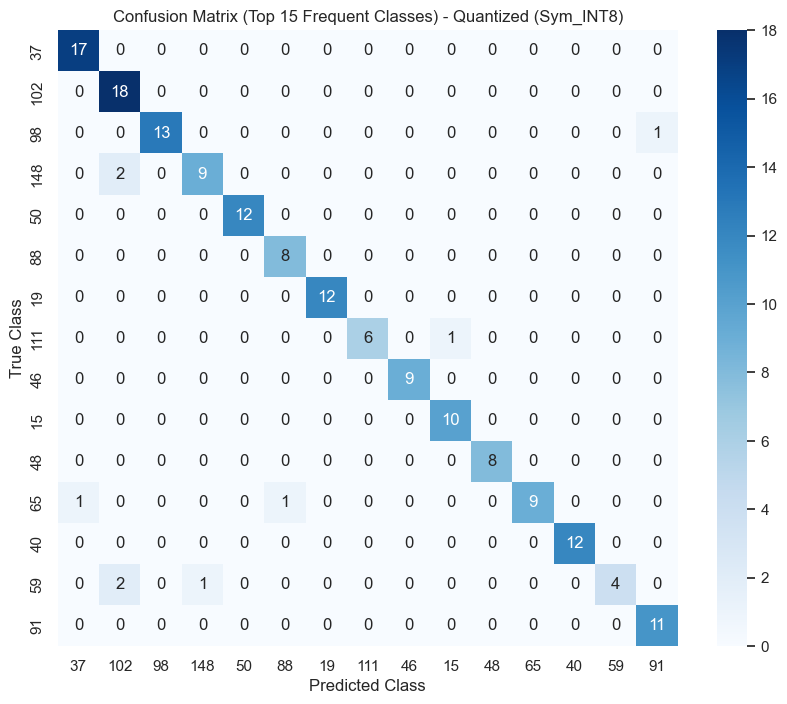


FAZIT: Accuracy Drop: 0.22% (Float: 75.29% -> Int8: 75.07%)


In [34]:
acc_base = assess_classification_performance(
    baseline_model, 
    test_loader, 
    DEVICE, 
    model_name="Baseline (Float32)"
)

acc_quant = assess_classification_performance(
    quantized_model, 
    test_loader, 
    DEVICE, 
    model_name=f"Quantized ({config_name})"
)

diff = acc_base - acc_quant
print("\n==================================================")
print(f"FAZIT: Accuracy Drop: {diff*100:.2f}% (Float: {acc_base*100:.2f}% -> Int8: {acc_quant*100:.2f}%)")
print("==================================================")

Zeige 50 Bilder. Legende: Grün=Korrekt, Rot=Falsch, Orange=Quantisierung weicht ab


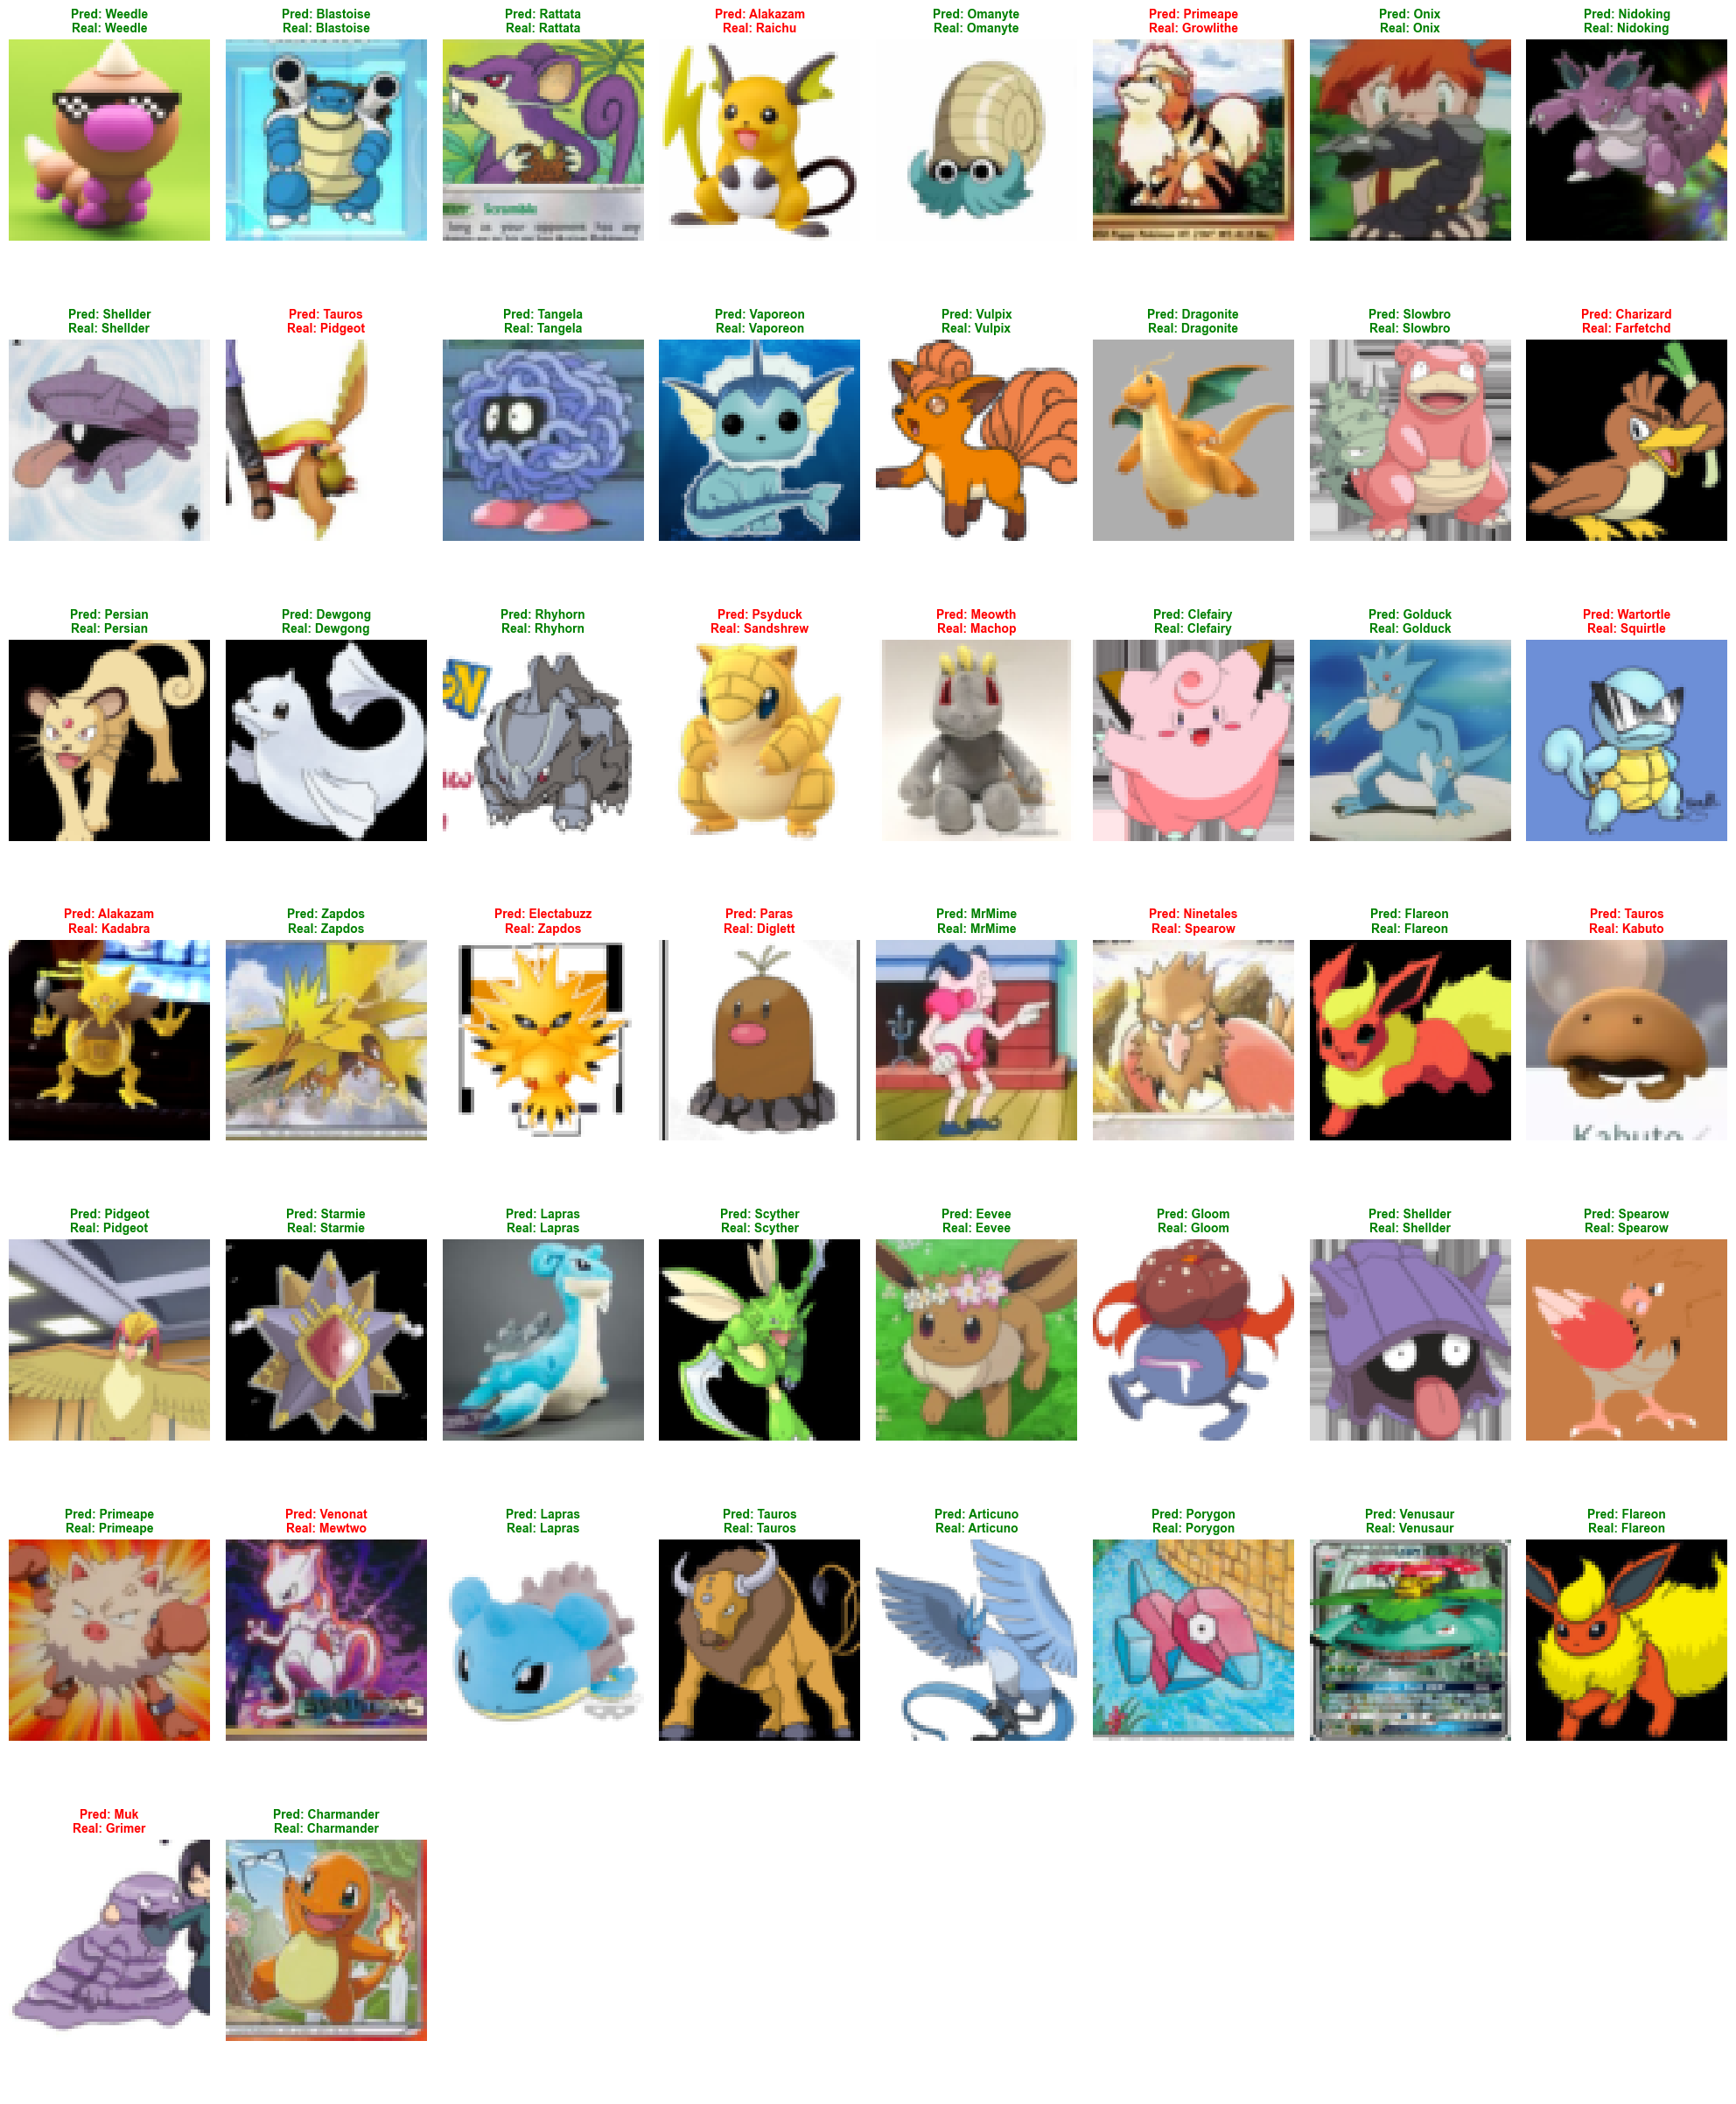

In [35]:

visualize_comparison(model_f=baseline_model, model_q=quantized_model, test_loader=test_loader, num_images=50)


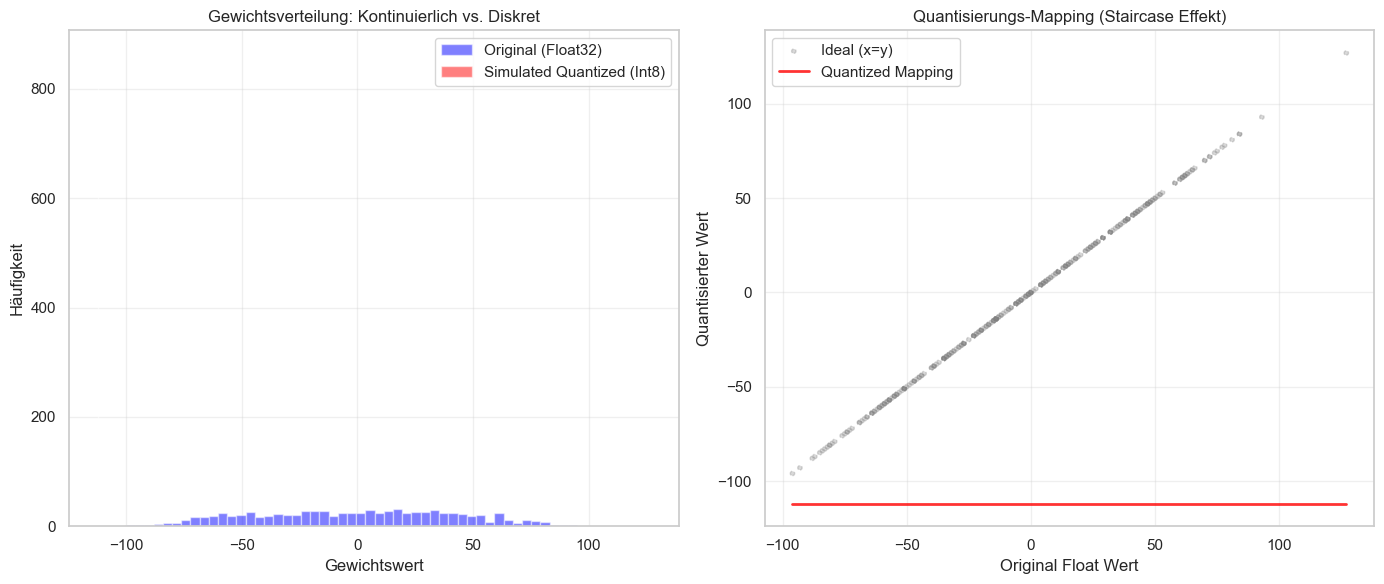

In [36]:


weights_floats = quantized_model.conv1.weight.data.clone().cpu()

weights_dequant, _, _, _ = Quantization.affine_quantization(weights_floats, num_bits=8)


flat_float = weights_floats.view(-1).numpy()
flat_dequant = weights_dequant.view(-1).numpy()

plt.figure(figsize=(14,6))

plt.subplot(1,2,1)

plt.hist(flat_float, bins=60, color='blue', alpha=0.5, label="Original (Float32)")
plt.hist(flat_dequant, bins=60, color='red', alpha=0.5, label="Simulated Quantized (Int8)")

plt.title("Gewichtsverteilung: Kontinuierlich vs. Diskret")
plt.xlabel("Gewichtswert")
plt.ylabel("Häufigkeit")
plt.legend()
plt.grid(True, alpha=0.3)


plt.subplot(1,2,2)


num_samples = 300
if len(flat_float) > num_samples:
    rand_idx = np.random.choice(len(flat_float), num_samples, replace=False)

    subset_idx = rand_idx[np.argsort(flat_float[rand_idx])]
else:
    subset_idx = np.argsort(flat_float)

plt.scatter(flat_float[subset_idx], flat_float[subset_idx], 
            color='gray', alpha=0.3, label="Ideal (x=y)", s=10, linestyle='--')
            
plt.plot(flat_float[subset_idx], flat_dequant[subset_idx], 
            color='red', alpha=0.8, label="Quantized Mapping", linewidth=2)

plt.title("Quantisierungs-Mapping (Staircase Effekt)")
plt.xlabel("Original Float Wert")
plt.ylabel("Quantisierter Wert")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()